# EDA — BTXRD (figshare) and MURA

Exploratory analysis of the two bone-tumor / bone-abnormality datasets we're using. Two halves:

- **Part A — BTXRD** (sections 1–6): label distributions, demographics, anatomy/view breakdowns, tumor subtypes, image characteristics.
- **Part B — MURA** (sections 7–10): label distribution by body part, study-level vs image-level labels, image characteristics.

Same path-resolution logic as the other notebooks, so this can sit in the repo root next to `baseline_models.ipynb`, `svm_baseline.ipynb`, etc.

In [1]:
import importlib.util
import subprocess
import sys
import random
from pathlib import Path
from typing import Optional

if importlib.util.find_spec("openpyxl") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

## 1. paths and configuration

In [2]:
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "data").is_dir():
    REPO_ROOT = Path.cwd().resolve().parent
DATA_ROOT = REPO_ROOT / "data"

# BTXRD
BTXRD_ROOT = DATA_ROOT / "BTXRD"
BTXRD_IMAGES = BTXRD_ROOT / "images"
BTXRD_XLSX = BTXRD_ROOT / "dataset.xlsx"

# MURA: usually unpacks as data/MURA-v1.1/{train,valid,...}
# We try the standard layout but fall back to anything matching.
MURA_CANDIDATES = [
    DATA_ROOT / "MURA-v1.1",
    DATA_ROOT / "MURA",
]
MURA_ROOT = next((p for p in MURA_CANDIDATES if p.is_dir()), None)

# How many images to sample for image-characteristic stats (resolution, intensity).
# Loading all 3700 BTXRD images takes a couple minutes; loading all 40k MURA
# images takes much longer. Sampling gives ~the same distribution stats faster.
IMG_STATS_SAMPLE = 400

print("DATA_ROOT:    ", DATA_ROOT)
print("BTXRD images: ", BTXRD_IMAGES, "(exists:", BTXRD_IMAGES.is_dir(), ")")
print("BTXRD xlsx:   ", BTXRD_XLSX, "(exists:", BTXRD_XLSX.is_file(), ")")
print("MURA root:    ", MURA_ROOT)

DATA_ROOT:     C:\Users\Constance\Documents\foar skuul frum kani\sem 4 - uh spring 2026\ds2\bone project\data
BTXRD images:  C:\Users\Constance\Documents\foar skuul frum kani\sem 4 - uh spring 2026\ds2\bone project\data\BTXRD\images (exists: True )
BTXRD xlsx:    C:\Users\Constance\Documents\foar skuul frum kani\sem 4 - uh spring 2026\ds2\bone project\data\BTXRD\dataset.xlsx (exists: True )
MURA root:     C:\Users\Constance\Documents\foar skuul frum kani\sem 4 - uh spring 2026\ds2\bone project\data\MURA-v1.1


# Part A — BTXRD

## 2. load btxrd labels and resolve image paths

drops any rows whose image file is missing on disk.

In [3]:
def resolve_image_path(images_dir: Path, image_id: str) -> Optional[Path]:
    p = images_dir / str(image_id).strip()
    if p.is_file():
        return p
    stem = Path(str(image_id)).stem
    for ext in (".jpeg", ".jpg", ".png", ".JPEG", ".JPG", ".PNG"):
        c = images_dir / f"{stem}{ext}"
        if c.is_file():
            return c
    return None


btxrd_raw = pd.read_excel(BTXRD_XLSX, engine="openpyxl")
btxrd_raw.columns = [str(c).strip() for c in btxrd_raw.columns]

# Attach resolved file path; drop rows whose image isn't on disk.
btxrd_raw["path"] = btxrd_raw["image_id"].apply(
    lambda x: resolve_image_path(BTXRD_IMAGES, x)
)
btxrd = btxrd_raw[btxrd_raw["path"].notna()].reset_index(drop=True).copy()
btxrd["path"] = btxrd["path"].apply(lambda p: p.as_posix())

print("Rows in xlsx:        ", len(btxrd_raw))
print("Rows with image file:", len(btxrd))
print("Columns:             ", len(btxrd.columns))
btxrd.head(3)

Rows in xlsx:         3746
Rows with image file: 3746
Columns:              38


,image_id,center,age,gender,hand,ulna,radius,humerus,foot,tibia,fibula,femur,hip bone,ankle-joint,knee-joint,hip-joint,wrist-joint,elbow-joint,shoulder-joint,tumor,benign,malignant,osteochondroma,multiple osteochondromas,simple bone cyst,giant cell tumor,osteofibroma,synovial osteochondroma,other bt,osteosarcoma,other mt,upper limb,lower limb,pelvis,frontal,lateral,oblique,path
0,IMG000001.jpeg,1,48,F,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,C:/Users/Constance/Documents/foar skuul frum k...
1,IMG000002.jpeg,1,12,M,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,C:/Users/Constance/Documents/foar skuul frum k...
2,IMG000003.jpeg,1,12,M,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,C:/Users/Constance/Documents/foar skuul frum k...


In [4]:
# Group columns by what they describe so the rest of the EDA is easier to write.
META_COLS = ["image_id", "path", "center", "age", "gender"]
BONE_COLS = [
    "hand", "ulna", "radius", "humerus", "foot",
    "tibia", "fibula", "femur", "hip bone",
]
JOINT_COLS = [
    "ankle-joint", "knee-joint", "hip-joint",
    "wrist-joint", "elbow-joint", "shoulder-joint",
]
REGION_COLS = ["upper limb", "lower limb", "pelvis"]
VIEW_COLS = ["frontal", "lateral", "oblique"]
TUMOR_LABEL_COLS = ["tumor", "benign", "malignant"]
BENIGN_SUBTYPE_COLS = [
    "osteochondroma", "multiple osteochondromas", "simple bone cyst",
    "giant cell tumor", "osteofibroma", "synovial osteochondroma", "other bt",
]
MALIGNANT_SUBTYPE_COLS = ["osteosarcoma", "other mt"]

print("meta:           ", META_COLS)
print("bones:          ", BONE_COLS)
print("joints:         ", JOINT_COLS)
print("regions:        ", REGION_COLS)
print("views:          ", VIEW_COLS)
print("tumor labels:   ", TUMOR_LABEL_COLS)
print("benign subtypes:", BENIGN_SUBTYPE_COLS)
print("malig subtypes: ", MALIGNANT_SUBTYPE_COLS)

meta:            ['image_id', 'path', 'center', 'age', 'gender']
bones:           ['hand', 'ulna', 'radius', 'humerus', 'foot', 'tibia', 'fibula', 'femur', 'hip bone']
joints:          ['ankle-joint', 'knee-joint', 'hip-joint', 'wrist-joint', 'elbow-joint', 'shoulder-joint']
regions:         ['upper limb', 'lower limb', 'pelvis']
views:           ['frontal', 'lateral', 'oblique']
tumor labels:    ['tumor', 'benign', 'malignant']
benign subtypes: ['osteochondroma', 'multiple osteochondromas', 'simple bone cyst', 'giant cell tumor', 'osteofibroma', 'synovial osteochondroma', 'other bt']
malig subtypes:  ['osteosarcoma', 'other mt']


## 3. btxrd label distributions

In [5]:
# Top-level: tumor / no tumor, and benign vs malignant within tumor cases.
n = len(btxrd)
n_tumor = int(btxrd["tumor"].sum())
n_benign = int(btxrd["benign"].sum())
n_malig = int(btxrd["malignant"].sum())
n_none = n - n_tumor

print(f"Total samples: {n}")
print(f"  no tumor:  {n_none:5d} ({n_none / n:.1%})")
print(f"  tumor:     {n_tumor:5d} ({n_tumor / n:.1%})")
print(f"    benign:    {n_benign:5d} ({n_benign / n_tumor:.1%} of tumors)")
print(f"    malignant: {n_malig:5d} ({n_malig / n_tumor:.1%} of tumors)")

# Sanity check that benign+malignant == tumor (no row should be tumor=1 without
# being either benign or malignant).
mismatch = btxrd[(btxrd["tumor"] == 1) & (btxrd["benign"] + btxrd["malignant"] == 0)]
print(f"\nTumor rows missing both subtype flags: {len(mismatch)}")

Total samples: 3746
  no tumor:   1879 (50.2%)
  tumor:      1867 (49.8%)
    benign:     1525 (81.7% of tumors)
    malignant:   342 (18.3% of tumors)

Tumor rows missing both subtype flags: 0


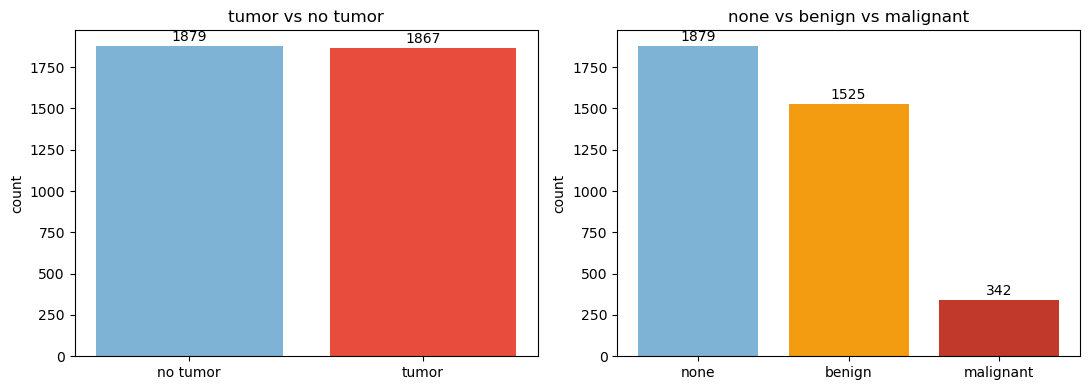

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Binary tumor balance
axes[0].bar(["no tumor", "tumor"], [n_none, n_tumor], color=["#7fb3d5", "#e74c3c"])
axes[0].set_title("tumor vs no tumor")
axes[0].set_ylabel("count")
for i, v in enumerate([n_none, n_tumor]):
    axes[0].text(i, v + 30, str(v), ha="center")

# 3-class
axes[1].bar(["none", "benign", "malignant"], [n_none, n_benign, n_malig],
            color=["#7fb3d5", "#f39c12", "#c0392b"])
axes[1].set_title("none vs benign vs malignant")
axes[1].set_ylabel("count")
for i, v in enumerate([n_none, n_benign, n_malig]):
    axes[1].text(i, v + 30, str(v), ha="center")

plt.tight_layout()
plt.show()

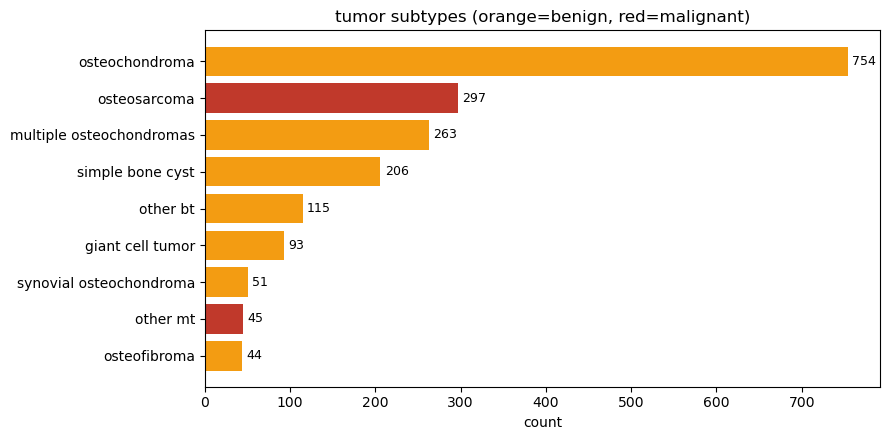


Malignancy is rare — osteosarcoma + other_mt = 342 of 1867 tumor cases


In [7]:
# Tumor subtype breakdown (of patients who have a tumor).
subtype_counts = pd.Series({
    c: int(btxrd[c].sum()) for c in BENIGN_SUBTYPE_COLS + MALIGNANT_SUBTYPE_COLS
}).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [
    "#c0392b" if c in MALIGNANT_SUBTYPE_COLS else "#f39c12"
    for c in subtype_counts.index
]
ax.barh(subtype_counts.index, subtype_counts.values, color=colors)
ax.set_xlabel("count")
ax.set_title("tumor subtypes (orange=benign, red=malignant)")
for i, v in enumerate(subtype_counts.values):
    ax.text(v + 5, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\nMalignancy is rare — osteosarcoma + other_mt =",
      int(btxrd[MALIGNANT_SUBTYPE_COLS].sum().sum()),
      "of", n_tumor, "tumor cases")

In [8]:
# Some images probably have multiple subtype flags set (e.g., osteochondroma
# AND multiple_osteochondromas). Quick check.
all_subtypes = BENIGN_SUBTYPE_COLS + MALIGNANT_SUBTYPE_COLS
subtype_count_per_img = btxrd[all_subtypes].sum(axis=1)
tumor_only = btxrd[btxrd["tumor"] == 1]

print("Subtype flags per tumor image:")
print(subtype_count_per_img[btxrd["tumor"] == 1].value_counts().sort_index())
print()
print("(0 = tumor labeled but no subtype recorded; >1 = multiple subtypes flagged)")

Subtype flags per tumor image:
1    1866
2       1
Name: count, dtype: int64

(0 = tumor labeled but no subtype recorded; >1 = multiple subtypes flagged)


## 4. btxrd demographics and acquisition

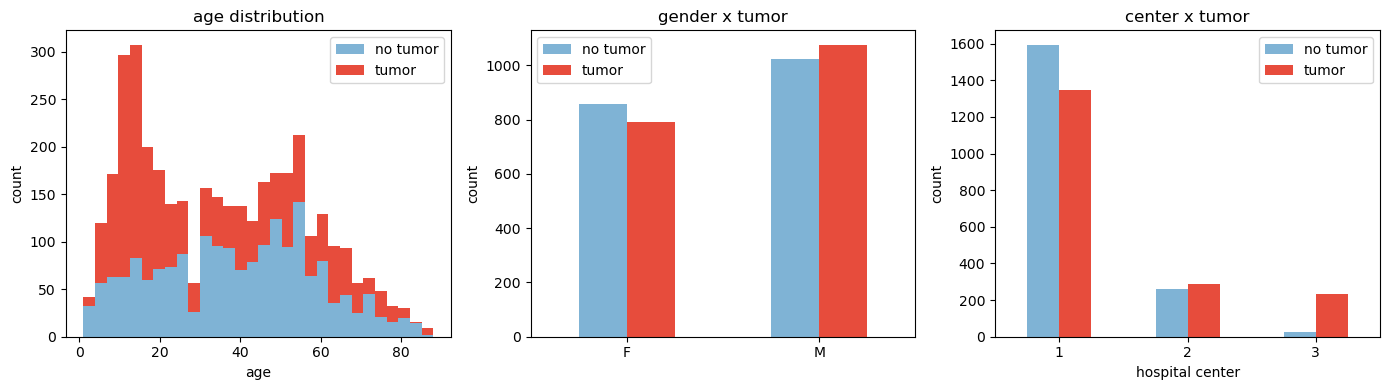


Age stats:
count    3746.00
mean       35.29
std        20.90
min         1.00
25%        16.00
50%        34.00
75%        53.00
max        88.00
Name: age, dtype: float64

Gender:
gender
M    2098
F    1648
Name: count, dtype: int64

Center:
center
1    2938
2     549
3     259
Name: count, dtype: int64


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Age distribution overall and by tumor status
axes[0].hist([btxrd.loc[btxrd["tumor"] == 0, "age"], btxrd.loc[btxrd["tumor"] == 1, "age"]],
             bins=30, stacked=True, label=["no tumor", "tumor"],
             color=["#7fb3d5", "#e74c3c"])
axes[0].set_title("age distribution")
axes[0].set_xlabel("age")
axes[0].set_ylabel("count")
axes[0].legend()

# Gender breakdown
g_counts = btxrd.groupby(["gender", "tumor"]).size().unstack(fill_value=0)
g_counts.columns = ["no tumor", "tumor"]
g_counts.plot(kind="bar", ax=axes[1], color=["#7fb3d5", "#e74c3c"], rot=0)
axes[1].set_title("gender x tumor")
axes[1].set_xlabel("")
axes[1].set_ylabel("count")

# Hospital center breakdown
c_counts = btxrd.groupby(["center", "tumor"]).size().unstack(fill_value=0)
c_counts.columns = ["no tumor", "tumor"]
c_counts.plot(kind="bar", ax=axes[2], color=["#7fb3d5", "#e74c3c"], rot=0)
axes[2].set_title("center x tumor")
axes[2].set_xlabel("hospital center")
axes[2].set_ylabel("count")

plt.tight_layout()
plt.show()

print("\nAge stats:")
print(btxrd["age"].describe().round(2))
print("\nGender:")
print(btxrd["gender"].value_counts())
print("\nCenter:")
print(btxrd["center"].value_counts().sort_index())

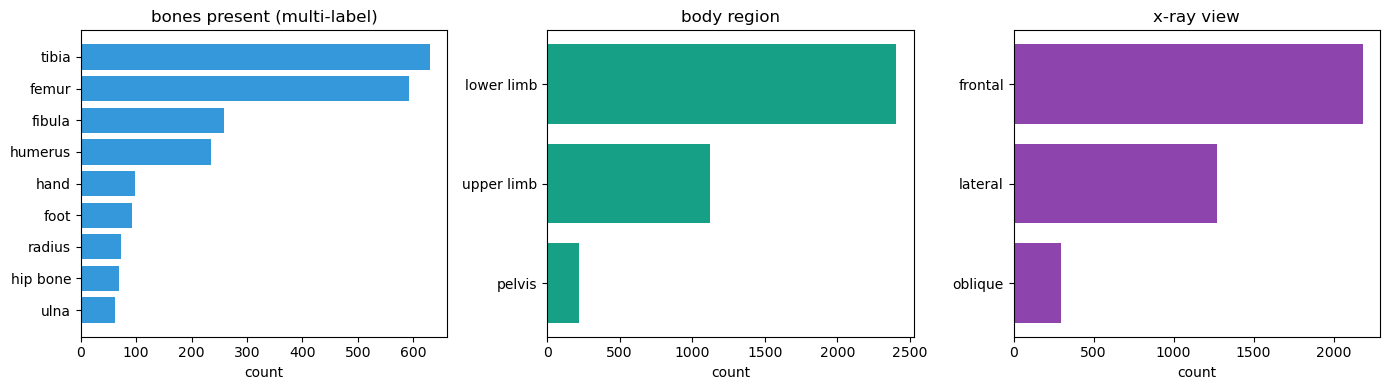

In [10]:
# Bone / region / view breakdowns. Each row can have multiple bones flagged
# (e.g., wrist x-ray covers ulna+radius), so these are not mutually exclusive.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

bone_counts = btxrd[BONE_COLS].sum().sort_values()
axes[0].barh(bone_counts.index, bone_counts.values, color="#3498db")
axes[0].set_title("bones present (multi-label)")
axes[0].set_xlabel("count")

region_counts = btxrd[REGION_COLS].sum().sort_values()
axes[1].barh(region_counts.index, region_counts.values, color="#16a085")
axes[1].set_title("body region")
axes[1].set_xlabel("count")

view_counts = btxrd[VIEW_COLS].sum().sort_values()
axes[2].barh(view_counts.index, view_counts.values, color="#8e44ad")
axes[2].set_title("x-ray view")
axes[2].set_xlabel("count")

plt.tight_layout()
plt.show()

In [11]:
# Tumor rate by region — does any body part have a much higher tumor rate?
rows = []
for c in REGION_COLS + BONE_COLS:
    sub = btxrd[btxrd[c] == 1]
    if len(sub) == 0:
        continue
    rows.append({
        "location": c,
        "n_images": len(sub),
        "tumor_rate": round(sub["tumor"].mean(), 3),
        "malignant_rate": round(sub["malignant"].mean(), 3),
    })
loc_df = pd.DataFrame(rows).sort_values("tumor_rate", ascending=False)
loc_df

,location,n_images,tumor_rate,malignant_rate
3,hand,97,1.000,0.031
6,humerus,235,1.000,0.277
5,radius,73,1.000,0.082
4,ulna,62,1.000,0.129
8,tibia,630,1.000,0.090
9,fibula,259,1.000,0.081
10,femur,592,1.000,0.267
7,foot,93,1.000,0.032
11,hip bone,69,1.000,0.348
1,lower limb,2406,0.545,0.096


## 5. btxrd image characteristics

samples 400 images to estimate resolution and intensity stats; loads a small grid for visual inspection.

In [12]:
# Sample for image-level stats. We need width, height, mode, and per-image
# mean intensity to characterize the dataset.
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(btxrd), size=min(IMG_STATS_SAMPLE, len(btxrd)), replace=False)
sample = btxrd.iloc[sample_idx].reset_index(drop=True)

stats = []
for p in sample["path"]:
    try:
        with Image.open(p) as img:
            w, h = img.size
            mode = img.mode
            arr = np.asarray(img.convert("L"), dtype=np.float32)
        stats.append({
            "width": w, "height": h, "mode": mode,
            "mean_intensity": float(arr.mean()),
            "std_intensity": float(arr.std()),
        })
    except Exception as e:
        stats.append({"width": np.nan, "height": np.nan, "mode": str(e),
                      "mean_intensity": np.nan, "std_intensity": np.nan})

stats_df = pd.DataFrame(stats)
print(f"Sampled {len(stats_df)} BTXRD images\n")
print(stats_df[["width", "height", "mean_intensity", "std_intensity"]].describe().round(2))
print("\nPIL color modes:")
print(stats_df["mode"].value_counts())

Sampled 400 BTXRD images

         width   height  mean_intensity  std_intensity
count   400.00   400.00          400.00         400.00
mean   1653.71  2186.39           67.94          55.35
std     650.50   828.23           23.48          12.90
min     270.00   429.00            9.08          11.29
25%    1250.00  1540.50           52.98          48.79
50%    1622.00  2305.00           64.97          56.66
75%    2128.00  2947.50           80.02          63.23
max    3162.00  4295.00          189.94          95.91

PIL color modes:
mode
L      307
RGB     93
Name: count, dtype: int64


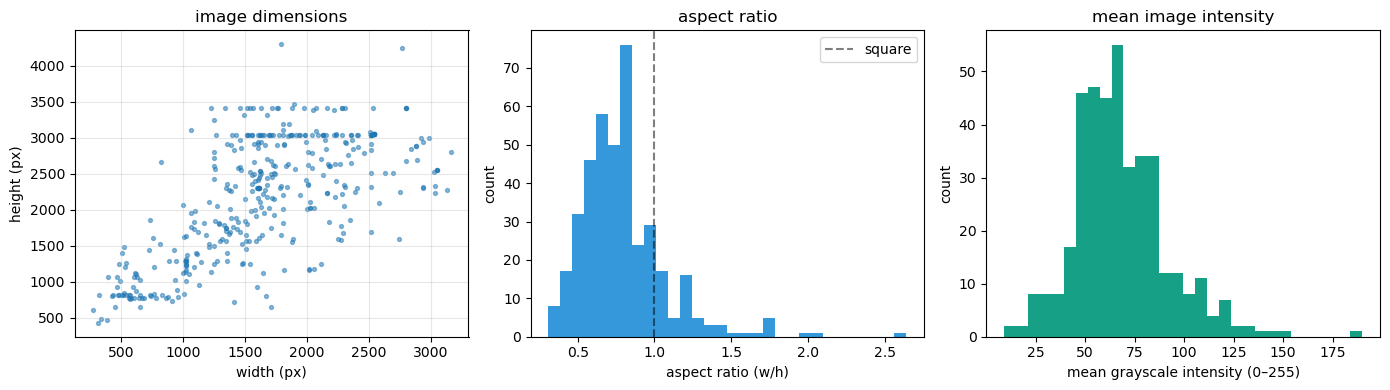

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(stats_df["width"], stats_df["height"], s=8, alpha=0.5)
axes[0].set_xlabel("width (px)")
axes[0].set_ylabel("height (px)")
axes[0].set_title("image dimensions")
axes[0].grid(alpha=0.3)

ar = (stats_df["width"] / stats_df["height"]).dropna()
axes[1].hist(ar, bins=30, color="#3498db")
axes[1].axvline(1.0, color="k", linestyle="--", alpha=0.5, label="square")
axes[1].set_xlabel("aspect ratio (w/h)")
axes[1].set_ylabel("count")
axes[1].set_title("aspect ratio")
axes[1].legend()

axes[2].hist(stats_df["mean_intensity"].dropna(), bins=30, color="#16a085")
axes[2].set_xlabel("mean grayscale intensity (0–255)")
axes[2].set_ylabel("count")
axes[2].set_title("mean image intensity")

plt.tight_layout()
plt.show()

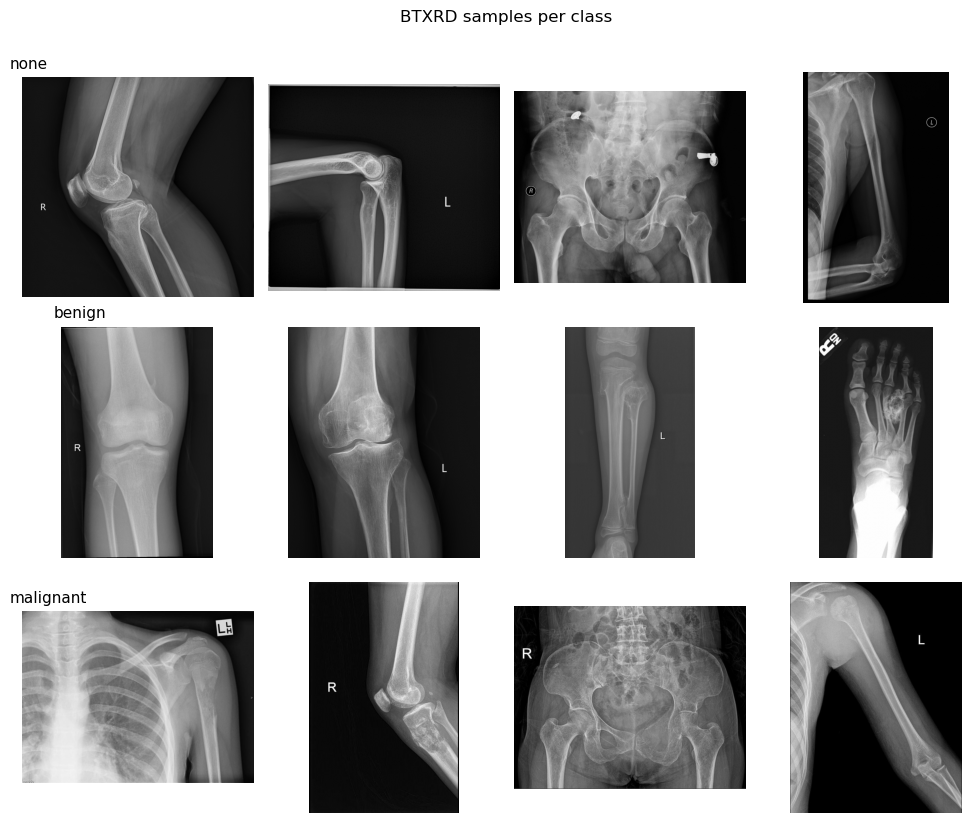

In [14]:
# Visual sanity check: 4 examples per class.
def show_class_grid(df_, label_filter, title, n_per_class=4):
    classes = list(label_filter.items())
    fig, axes = plt.subplots(len(classes), n_per_class,
                             figsize=(n_per_class * 2.5, len(classes) * 2.7))
    if len(classes) == 1:
        axes = np.array([axes])
    for row, (name, mask) in enumerate(classes):
        sub = df_[mask].sample(n=min(n_per_class, mask.sum()), random_state=RANDOM_STATE)
        for col in range(n_per_class):
            ax = axes[row, col]
            if col < len(sub):
                img = Image.open(sub.iloc[col]["path"]).convert("L")
                ax.imshow(img, cmap="gray")
            ax.axis("off")
            if col == 0:
                ax.set_title(name, loc="left", fontsize=11, x=-0.05)
    fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()


show_class_grid(
    btxrd,
    {
        "none":      btxrd["tumor"] == 0,
        "benign":    btxrd["benign"] == 1,
        "malignant": btxrd["malignant"] == 1,
    },
    title="BTXRD samples per class",
)

## 6. btxrd takeaways

In [15]:
summary_btxrd = pd.Series({
    "n_images": len(btxrd),
    "tumor_rate": round(btxrd["tumor"].mean(), 3),
    "benign_of_tumor": round(btxrd["benign"].sum() / btxrd["tumor"].sum(), 3),
    "malignant_of_tumor": round(btxrd["malignant"].sum() / btxrd["tumor"].sum(), 3),
    "n_centers": btxrd["center"].nunique(),
    "age_min": int(btxrd["age"].min()),
    "age_median": int(btxrd["age"].median()),
    "age_max": int(btxrd["age"].max()),
    "sample_width_median": int(stats_df["width"].median()),
    "sample_height_median": int(stats_df["height"].median()),
    "sample_mean_intensity": round(float(stats_df["mean_intensity"].mean()), 1),
})
summary_btxrd

n_images                 3746.000
tumor_rate                  0.498
benign_of_tumor             0.817
malignant_of_tumor          0.183
n_centers                   3.000
age_min                     1.000
age_median                 34.000
age_max                    88.000
sample_width_median      1622.000
sample_height_median     2305.000
sample_mean_intensity      67.900
dtype: float64

# Part B — MURA

## 7. load mura paths

MURA encodes labels in the file path: `train/XR_BODYPART/patientNNNNN/studyN_(positive|negative)/imageN.png`. We parse those segments into columns.

In [16]:
def parse_mura_path(rel: str) -> dict:
    """Pull body part, patient id, study id, label out of a MURA path."""
    parts = rel.replace("\\", "/").split("/")
    # Expected: ['MURA-v1.1', 'train', 'XR_SHOULDER', 'patient00001', 'study1_positive', 'imageN.png']
    if len(parts) < 6:
        return {"split": None, "body_part": None, "patient": None,
                "study": None, "label": None, "file": None}
    split = parts[1]
    body_part = parts[2].replace("XR_", "")
    patient = parts[3]
    study_dir = parts[4]
    label = "positive" if "positive" in study_dir else ("negative" if "negative" in study_dir else None)
    return {
        "split": split,
        "body_part": body_part,
        "patient": patient,
        "study": f"{patient}/{study_dir}",
        "label": label,
        "file": parts[-1],
    }


if MURA_ROOT is None:
    print("MURA folder not found in data/. Skipping Part B.")
    mura = pd.DataFrame()
else:
    # Prefer the official path csvs if present (in MURA-v1.1/), otherwise glob.
    train_csv = MURA_ROOT / "train_image_paths.csv"
    valid_csv = MURA_ROOT / "valid_image_paths.csv"

    if train_csv.is_file() and valid_csv.is_file():
        train_paths = pd.read_csv(train_csv, header=None, names=["rel_path"])
        valid_paths = pd.read_csv(valid_csv, header=None, names=["rel_path"])
        all_paths = pd.concat([train_paths, valid_paths], ignore_index=True)
        print(f"Loaded {len(train_paths)} train + {len(valid_paths)} valid paths from csv.")
    else:
        # Fallback: walk the directory. Slower but works without the csvs.
        rels = []
        for split in ("train", "valid"):
            split_dir = MURA_ROOT / split
            if not split_dir.is_dir():
                continue
            for p in split_dir.rglob("*.png"):
                rels.append(p.relative_to(MURA_ROOT.parent).as_posix())
        all_paths = pd.DataFrame({"rel_path": rels})
        print(f"Walked filesystem, found {len(all_paths)} png files.")

    parsed = pd.DataFrame([parse_mura_path(p) for p in all_paths["rel_path"]])
    mura = pd.concat([all_paths, parsed], axis=1)
    # Build absolute path for image loading later. The csv paths are relative
    # to MURA_ROOT.parent (they include the 'MURA-v1.1/' prefix).
    mura["abs_path"] = mura["rel_path"].apply(lambda r: (MURA_ROOT.parent / r).as_posix())
    print("\nParsed columns:", list(mura.columns))
    mura.head(3)

Loaded 36808 train + 3197 valid paths from csv.

Parsed columns: ['rel_path', 'split', 'body_part', 'patient', 'study', 'label', 'file', 'abs_path']


In [17]:
if len(mura):
    print("Splits:", mura["split"].value_counts().to_dict())
    print("Body parts:", mura["body_part"].value_counts().to_dict())
    print("Image-level labels:", mura["label"].value_counts().to_dict())
    print("Unique patients:", mura["patient"].nunique())
    print("Unique studies:", mura["study"].nunique())

Splits: {'train': 36808, 'valid': 3197}
Body parts: {'WRIST': 10411, 'SHOULDER': 8942, 'HAND': 6003, 'FINGER': 5567, 'ELBOW': 5396, 'FOREARM': 2126, 'HUMERUS': 1560}
Image-level labels: {'negative': 23602, 'positive': 16403}
Unique patients: 11967
Unique studies: 13457


## 8. mura label distribution by body part

MURA labels live at the **study** level — every image in a positive study inherits `positive`. So both image-level and study-level breakdowns are useful.

In [18]:
if len(mura):
    # Image-level
    img_breakdown = (mura.groupby(["body_part", "label"]).size()
                     .unstack(fill_value=0)
                     .assign(total=lambda x: x.sum(axis=1)))
    img_breakdown["positive_rate"] = (img_breakdown["positive"]
                                      / img_breakdown["total"]).round(3)
    img_breakdown = img_breakdown.sort_values("total", ascending=False)
    print("Image-level breakdown by body part:")
    print(img_breakdown)

    # Study-level: dedup on study, take the label.
    studies = mura.drop_duplicates("study")[["body_part", "label"]]
    stu_breakdown = (studies.groupby(["body_part", "label"]).size()
                     .unstack(fill_value=0)
                     .assign(total=lambda x: x.sum(axis=1)))
    stu_breakdown["positive_rate"] = (stu_breakdown["positive"]
                                      / stu_breakdown["total"]).round(3)
    stu_breakdown = stu_breakdown.sort_values("total", ascending=False)
    print("\nStudy-level breakdown by body part:")
    print(stu_breakdown)

Image-level breakdown by body part:
label      negative  positive  total  positive_rate
body_part                                          
WRIST          6129      4282  10411          0.411
SHOULDER       4496      4446   8942          0.497
HAND           4330      1673   6003          0.279
FINGER         3352      2215   5567          0.398
ELBOW          3160      2236   5396          0.414
FOREARM        1314       812   2126          0.382
HUMERUS         821       739   1560          0.474

Study-level breakdown by body part:
label      negative  positive  total  positive_rate
body_part                                          
WRIST          2073      1309   3382          0.387
SHOULDER       1441      1537   2978          0.516
FINGER         1283       679   1962          0.346
HAND           1319       526   1845          0.285
ELBOW          1066       661   1727          0.383
FOREARM         561       315    876          0.360
HUMERUS         364       323    687       

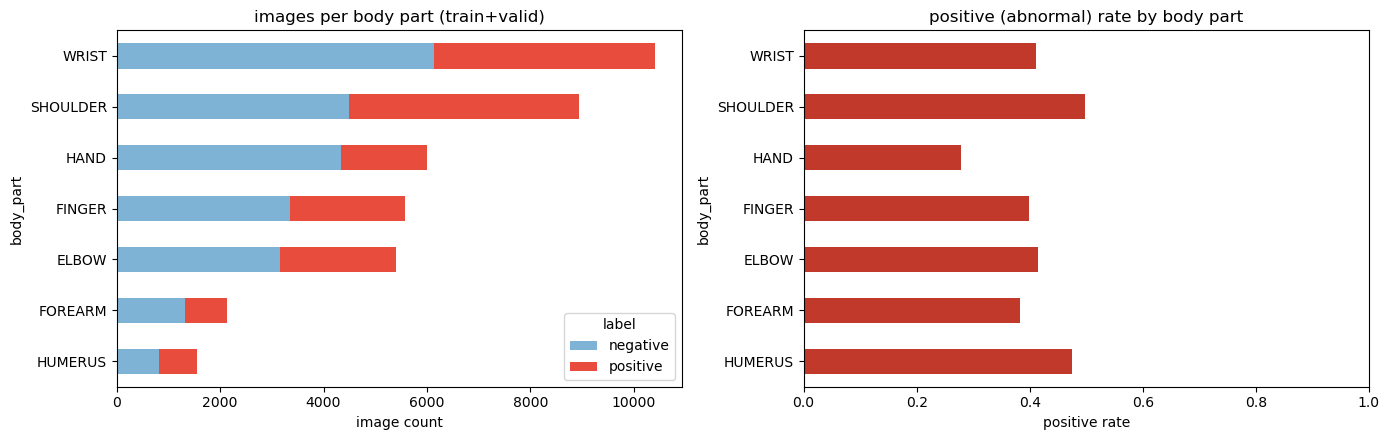

In [19]:
if len(mura):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    img_breakdown[["negative", "positive"]].plot(
        kind="barh", stacked=True, ax=axes[0],
        color=["#7fb3d5", "#e74c3c"],
    )
    axes[0].set_title("images per body part (train+valid)")
    axes[0].set_xlabel("image count")
    axes[0].invert_yaxis()

    img_breakdown["positive_rate"].plot(kind="barh", ax=axes[1], color="#c0392b")
    axes[1].set_title("positive (abnormal) rate by body part")
    axes[1].set_xlabel("positive rate")
    axes[1].invert_yaxis()
    axes[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

Images per study:
count    13457.00
mean         2.97
std          1.26
min          1.00
25%          2.00
50%          3.00
75%          3.00
max         14.00
dtype: float64


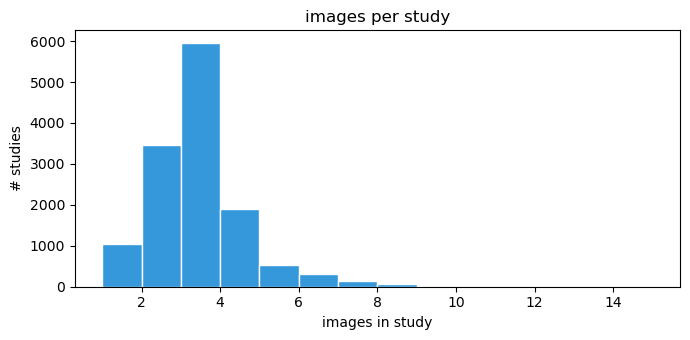

In [20]:
if len(mura):
    # How many images per study? Useful to know — papers often aggregate
    # predictions across a study's images.
    imgs_per_study = mura.groupby("study").size()
    print("Images per study:")
    print(imgs_per_study.describe().round(2))

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.hist(imgs_per_study, bins=range(1, imgs_per_study.max() + 2),
            color="#3498db", edgecolor="white")
    ax.set_xlabel("images in study")
    ax.set_ylabel("# studies")
    ax.set_title("images per study")
    plt.tight_layout()
    plt.show()

## 9. mura image characteristics

samples 400 images for resolution and intensity stats, plus an example grid.

In [21]:
if len(mura):
    rng = np.random.default_rng(RANDOM_STATE)
    sample_idx = rng.choice(len(mura), size=min(IMG_STATS_SAMPLE, len(mura)), replace=False)
    mura_sample = mura.iloc[sample_idx].reset_index(drop=True)

    m_stats = []
    for p in mura_sample["abs_path"]:
        try:
            with Image.open(p) as img:
                w, h = img.size
                mode = img.mode
                arr = np.asarray(img.convert("L"), dtype=np.float32)
            m_stats.append({
                "width": w, "height": h, "mode": mode,
                "mean_intensity": float(arr.mean()),
                "std_intensity": float(arr.std()),
            })
        except Exception as e:
            m_stats.append({"width": np.nan, "height": np.nan, "mode": str(e),
                            "mean_intensity": np.nan, "std_intensity": np.nan})

    m_stats_df = pd.DataFrame(m_stats)
    print(f"Sampled {len(m_stats_df)} MURA images\n")
    print(m_stats_df[["width", "height", "mean_intensity", "std_intensity"]].describe().round(2))
    print("\nPIL color modes:")
    print(m_stats_df["mode"].value_counts())

Sampled 400 MURA images

        width  height  mean_intensity  std_intensity
count  400.00  400.00          400.00         400.00
mean   403.02  491.34           53.08          31.70
std     92.81   46.06           30.58          12.73
min    139.00  195.00            3.41           9.85
25%    376.75  512.00           36.33          23.27
50%    406.00  512.00           47.00          29.13
75%    498.00  512.00           57.18          36.85
max    512.00  512.00          176.90          92.99

PIL color modes:
mode
L      245
RGB    155
Name: count, dtype: int64


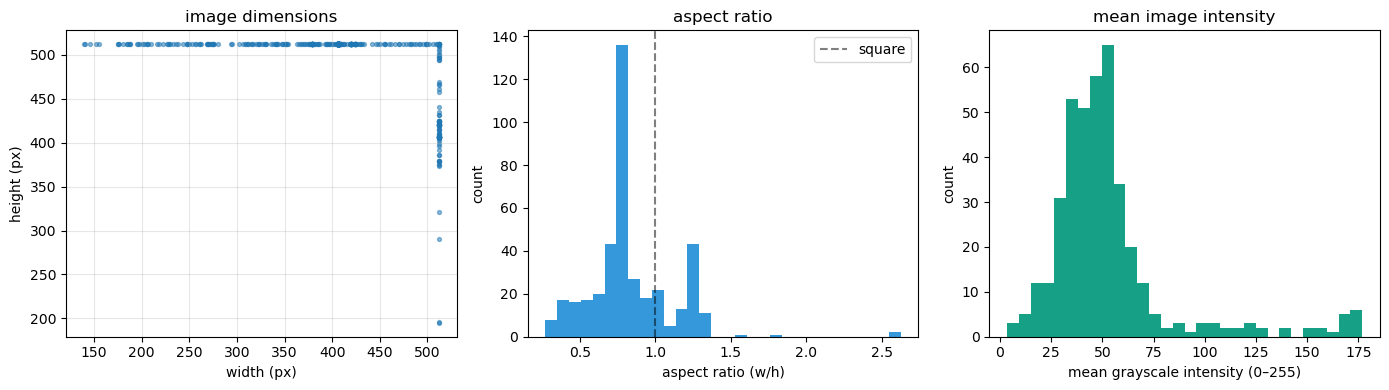

In [22]:
if len(mura):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].scatter(m_stats_df["width"], m_stats_df["height"], s=8, alpha=0.5)
    axes[0].set_xlabel("width (px)")
    axes[0].set_ylabel("height (px)")
    axes[0].set_title("image dimensions")
    axes[0].grid(alpha=0.3)

    ar = (m_stats_df["width"] / m_stats_df["height"]).dropna()
    axes[1].hist(ar, bins=30, color="#3498db")
    axes[1].axvline(1.0, color="k", linestyle="--", alpha=0.5, label="square")
    axes[1].set_xlabel("aspect ratio (w/h)")
    axes[1].set_ylabel("count")
    axes[1].set_title("aspect ratio")
    axes[1].legend()

    axes[2].hist(m_stats_df["mean_intensity"].dropna(), bins=30, color="#16a085")
    axes[2].set_xlabel("mean grayscale intensity (0–255)")
    axes[2].set_ylabel("count")
    axes[2].set_title("mean image intensity")

    plt.tight_layout()
    plt.show()

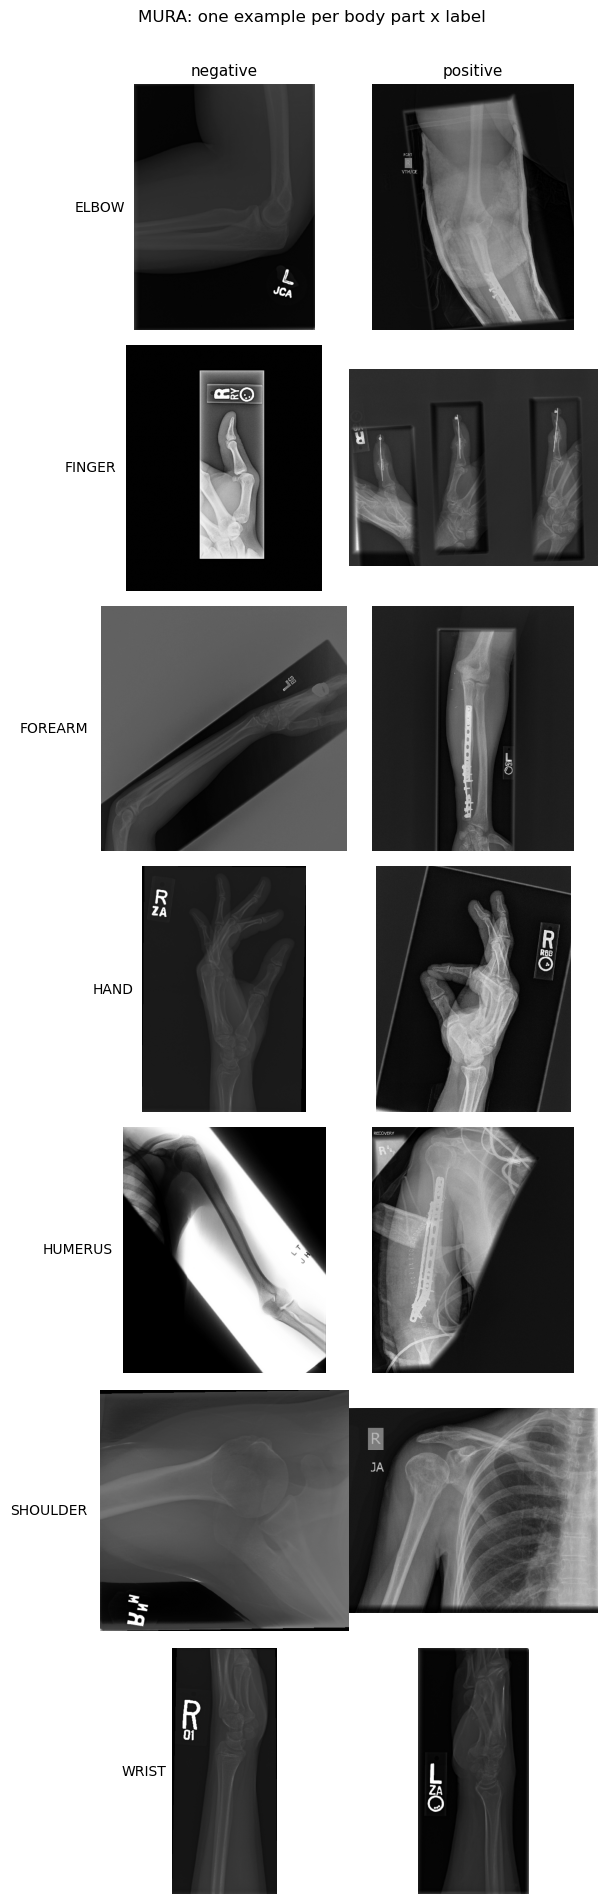

In [23]:
if len(mura):
    # Show one negative + one positive per body part.
    body_parts = sorted(mura["body_part"].dropna().unique())
    fig, axes = plt.subplots(len(body_parts), 2, figsize=(6, len(body_parts) * 2.7))
    for row, bp in enumerate(body_parts):
        for col, lab in enumerate(["negative", "positive"]):
            sub = mura[(mura["body_part"] == bp) & (mura["label"] == lab)]
            ax = axes[row, col]
            if len(sub):
                p = sub.sample(n=1, random_state=RANDOM_STATE).iloc[0]["abs_path"]
                try:
                    img = Image.open(p).convert("L")
                    ax.imshow(img, cmap="gray")
                except Exception:
                    pass
            ax.axis("off")
            if row == 0:
                ax.set_title(lab, fontsize=11)
            if col == 0:
                ax.set_ylabel(bp, fontsize=10, rotation=0, ha="right", va="center")
                ax.text(-0.05, 0.5, bp, transform=ax.transAxes,
                        ha="right", va="center", fontsize=10)
    fig.suptitle("MURA: one example per body part x label", y=1.005)
    plt.tight_layout()
    plt.show()

## 10. mura takeaways

In [24]:
if len(mura):
    summary_mura = pd.Series({
        "n_images": len(mura),
        "n_studies": mura["study"].nunique(),
        "n_patients": mura["patient"].nunique(),
        "n_body_parts": mura["body_part"].nunique(),
        "image_positive_rate": round((mura["label"] == "positive").mean(), 3),
        "sample_width_median": int(m_stats_df["width"].median()),
        "sample_height_median": int(m_stats_df["height"].median()),
        "sample_mean_intensity": round(float(m_stats_df["mean_intensity"].mean()), 1),
    })
    print(summary_mura)
else:
    print("MURA not loaded.")

n_images                 40005.00
n_studies                13457.00
n_patients               11967.00
n_body_parts                 7.00
image_positive_rate          0.41
sample_width_median        406.00
sample_height_median       512.00
sample_mean_intensity       53.10
dtype: float64
